# Decision Trees for Highly Cited Research Papers

This notebook predicts whether a research paper is highly cited instead of whether a song is popular.

## Setup

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

## Load Research Paper Data

In [2]:
# Load the joined OpenAlex + Semantic Scholar data used in the K-Means notebook.
DB_PATH = Path("papers.db")
if not DB_PATH.exists():
    DB_PATH = Path("../papers.db")

JOINED_QUERY = """
SELECT
    o.openalex_id,
    o.doi,
    o.doi_normalized,
    o.title,
    o.publication_year,
    o.cited_by_count,
    o.author_count,
    o.primary_topic,
    o.primary_subfield,
    o.primary_field,
    o.primary_domain,
    s.abstract_text,
    s.tldr_text
FROM openalex_papers AS o
JOIN semanticscholar_papers AS s
    ON o.doi_normalized = s.doi_normalized
WHERE s.abstract_text IS NOT NULL
  AND TRIM(s.abstract_text) <> ''
  AND s.tldr_text IS NOT NULL
  AND TRIM(s.tldr_text) <> ''
  AND o.cited_by_count IS NOT NULL
"""

with sqlite3.connect(DB_PATH) as conn:
    df = pl.read_database(query=JOINED_QUERY, connection=conn)

print(f"Joined rows with abstracts, TLDRs, and citation counts: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
df.head()

Joined rows with abstracts, TLDRs, and citation counts: 15042
Columns: 13


openalex_id,doi,doi_normalized,title,publication_year,cited_by_count,author_count,primary_topic,primary_subfield,primary_field,primary_domain,abstract_text,tldr_text
str,str,str,str,i64,i64,i64,str,str,str,str,str,str
"""https://openalex.org/W43627070…","""https://doi.org/10.1016/j.patc…","""10.1016/j.patcog.2026.113208""","""RFAConv: Receptive-field atten…",2026,86,7,"""Advanced Neural Network Applic…","""Computer Vision and Pattern Re…","""Computer Science""","""Physical Sciences""","""In the realm of deep learning,…","""It is revealed that current sp…"
"""https://openalex.org/W71290307…","""https://doi.org/10.1145/379651…","""10.1145/3796519""","""Model Context Protocol (MCP): …",2026,22,4,"""Security and Verification in C…","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""The Model Context Protocol (MC…","""A comprehensive threat taxonom…"
"""https://openalex.org/W44007028…","""https://doi.org/10.1109/tnnls.…","""10.1109/tnnls.2025.3646122""","""Graph Transformers: A Survey""",2026,16,7,"""Advanced Graph Neural Networks""","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""Graph transformers are a recen…","""This survey provides an in-dep…"
"""https://openalex.org/W43969140…","""https://doi.org/10.1007/s11263…","""10.1007/s11263-025-02646-6""","""Deep Learning-Based Object Pos…",2026,14,10,"""Hand Gesture Recognition Syste…","""Human-Computer Interaction""","""Computer Science""","""Physical Sciences""","""Object pose estimation is a fu…","""This survey discusses the rece…"
"""https://openalex.org/W44043502…","""https://doi.org/10.1038/s41567…","""10.1038/s41567-025-03144-9""","""Dynamical simulations of many-…",2026,9,19,"""Neural Networks and Reservoir …","""Artificial Intelligence""","""Computer Science""","""Physical Sciences""","""Quantum circuits with local un…","""This work studies dual-unitary…"


## Binarize Citation Popularity

The homework used `binarize_popularity` to mark songs as popular. Here, the same function name creates a `highly_cited` boolean label from `cited_by_count`.

In [3]:
def binarize_popularity(df: pl.DataFrame, threshold: int = 1) -> pl.DataFrame:
    """
    Add a 'highly_cited' boolean column indicating whether a paper is highly cited.

    Requirements:
    - Add a new column 'highly_cited' (boolean):
        - True if cited_by_count >= threshold
        - False if cited_by_count < threshold
    - Do not modify any existing columns

    Args:
        df: Polars DataFrame with a 'cited_by_count' column
        threshold: citation-count cutoff

    Returns:
        DataFrame with added 'highly_cited' boolean column

    Example:
        >>> sample = pl.DataFrame({'cited_by_count': [0, 1, 10]})
        >>> result = binarize_popularity(sample, threshold=1)
        >>> result['highly_cited'].to_list()
        [False, True, True]
    """
    return df.with_columns(
        (pl.col("cited_by_count").fill_null(0) >= threshold).alias("highly_cited")
    )


# Example test:
sample = pl.DataFrame({"cited_by_count": [0, 1, 10]})
binarize_popularity(sample, threshold=1)["highly_cited"].to_list()
# Expected: [False, True, True]

[False, True, True]

In [4]:
# The citation distribution is very skewed, so use the 95th percentile as a data-aware cutoff.
# For this dataset, that cutoff is 1 citation. Raise this manually for a stricter definition.
CITATION_THRESHOLD = max(
    1,
    int(df.select(pl.col("cited_by_count").quantile(0.95, interpolation="nearest")).item()),
)

df_labeled = binarize_popularity(df, threshold=CITATION_THRESHOLD)

label_counts = (
    df_labeled
    .group_by("highly_cited")
    .len()
    .with_columns((pl.col("len") / df_labeled.height).alias("fraction"))
    .sort("highly_cited")
)

print(f"Highly cited threshold: cited_by_count >= {CITATION_THRESHOLD}")
label_counts

Highly cited threshold: cited_by_count >= 1


highly_cited,len,fraction
bool,u32,f64
false,14154,0.940965
true,888,0.059035


## Prepare Features

`cited_by_count` is the target source, so it is intentionally excluded from the feature matrix. The features below use publication metadata plus abstract/TLDR text.

In [5]:
NUMERIC_FEATURES = ["publication_year", "log_author_count"]
CATEGORICAL_FEATURES = ["primary_topic", "primary_subfield", "primary_field", "primary_domain"]

numeric_matrix = df_labeled.select([
    pl.col("publication_year")
      .fill_null(pl.col("publication_year").median())
      .cast(pl.Float64)
      .alias("publication_year"),
    pl.col("author_count")
      .fill_null(0)
      .clip(lower_bound=0)
      .log1p()
      .cast(pl.Float64)
      .alias("log_author_count"),
]).to_numpy()

categorical_values = df_labeled.select([
    pl.col(column).fill_null("Unknown") for column in CATEGORICAL_FEATURES
]).to_numpy()

# min_frequency keeps the tree from splitting on many one-off topic labels.
categorical_encoder = OneHotEncoder(
    handle_unknown="ignore",
    min_frequency=20,
    sparse_output=True,
)
categorical_matrix = categorical_encoder.fit_transform(categorical_values)

# Keep text features compact so the tree can still be visualized and interpreted.
abstract_vectorizer = TfidfVectorizer(stop_words="english", max_features=200, min_df=5)
tldr_vectorizer = TfidfVectorizer(stop_words="english", max_features=100, min_df=5)

abstract_matrix = abstract_vectorizer.fit_transform(df_labeled["abstract_text"].fill_null("").to_list())
tldr_matrix = tldr_vectorizer.fit_transform(df_labeled["tldr_text"].fill_null("").to_list())

X = hstack([
    csr_matrix(numeric_matrix),
    categorical_matrix,
    abstract_matrix,
    tldr_matrix,
], format="csr")
y_binary = df_labeled["highly_cited"].to_numpy().astype(int)

feature_names = (
    NUMERIC_FEATURES
    + categorical_encoder.get_feature_names_out(CATEGORICAL_FEATURES).tolist()
    + [f"abstract:{term}" for term in abstract_vectorizer.get_feature_names_out()]
    + [f"tldr:{term}" for term in tldr_vectorizer.get_feature_names_out()]
)

print("Feature matrix shape:", X.shape)
print("Number of positive labels:", int(y_binary.sum()))
print("Number of feature names:", len(feature_names))

Feature matrix shape: (15042, 462)
Number of positive labels: 888
Number of feature names: 462


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train positives:", int(y_train.sum()))
print("Test positives:", int(y_test.sum()))

Train shape: (12033, 462)
Test shape: (3009, 462)
Train positives: 710
Test positives: 178


## Train Decision Trees at Several Depths

In [7]:
def train_decision_tree(
    X_train,
    y_train: np.ndarray,
    max_depth: int | None = 5,
    random_state: int = 42,
    class_weight: str | None = "balanced",
    min_samples_leaf: int = 200,
    min_samples_split: int = 400,
):
    """
    Train and return a DecisionTreeClassifier.

    This mirrors the homework function, with class_weight='balanced' added because
    the highly-cited class is much smaller than the not-highly-cited class.

    The min_samples_leaf and min_samples_split settings regularize the tree so it
    cannot make splits from tiny, noisy groups of papers.
    """
    model = DecisionTreeClassifier(
        max_depth=max_depth,
        random_state=random_state,
        class_weight=class_weight,
        min_samples_leaf=min_samples_leaf,
        min_samples_split=min_samples_split,
    )
    model.fit(X_train, y_train)
    return model

In [8]:
# Train at several depths to observe the effect with regularization.
for depth in [2, 3, 5, 8, 12, None]:
    model = train_decision_tree(X_train, y_train, max_depth=depth)
    label = str(depth) if depth is not None else "unlimited"
    print(
        f"max_depth={label:>9} | "
        f"actual_depth={model.tree_.max_depth:>3} | "
        f"leaves={model.tree_.n_leaves:>4} | "
        f"train_accuracy={model.score(X_train, y_train):.3f} | "
        f"min_samples_leaf={model.min_samples_leaf}"
    )

max_depth=        2 | actual_depth=  2 | leaves=   4 | train_accuracy=0.823 | min_samples_leaf=200
max_depth=        3 | actual_depth=  3 | leaves=   7 | train_accuracy=0.863 | min_samples_leaf=200
max_depth=        5 | actual_depth=  5 | leaves=  16 | train_accuracy=0.779 | min_samples_leaf=200
max_depth=        8 | actual_depth=  8 | leaves=  22 | train_accuracy=0.752 | min_samples_leaf=200
max_depth=       12 | actual_depth= 12 | leaves=  28 | train_accuracy=0.543 | min_samples_leaf=200
max_depth=unlimited | actual_depth= 23 | leaves=  46 | train_accuracy=0.606 | min_samples_leaf=200


## Evaluate Classifier

In [9]:
def evaluate_classifier(model, X_test, y_test: np.ndarray) -> dict:
    """
    Evaluate a classifier and return performance metrics.

    Returns accuracy, precision, recall, F1, and confusion-matrix counts.
    """
    y_pred = model.predict(X_test)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred, labels=[0, 1]).ravel()

    return {
        "accuracy": float(accuracy_score(y_test, y_pred)),
        "precision": float(precision_score(y_test, y_pred, zero_division=0)),
        "recall": float(recall_score(y_test, y_pred, zero_division=0)),
        "f1": float(f1_score(y_test, y_pred, zero_division=0)),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }

In [10]:
depth_results = []

for depth in [2, 3, 5, 8, 12, None]:
    model = train_decision_tree(X_train, y_train, max_depth=depth)
    metrics = evaluate_classifier(model, X_test, y_test)
    depth_results.append({
        "max_depth": str(depth) if depth is not None else "unlimited",
        "actual_depth": model.tree_.max_depth,
        "leaves": model.tree_.n_leaves,
        "min_samples_leaf": model.min_samples_leaf,
        "min_samples_split": model.min_samples_split,
        "train_accuracy": round(float(model.score(X_train, y_train)), 3),
        "test_accuracy": round(metrics["accuracy"], 3),
        "precision": round(metrics["precision"], 3),
        "recall": round(metrics["recall"], 3),
        "f1": round(metrics["f1"], 3),
        "false_positives": metrics["false_positives"],
        "false_negatives": metrics["false_negatives"],
    })

depth_results_df = pl.DataFrame(depth_results)
depth_results_df

max_depth,actual_depth,leaves,min_samples_leaf,min_samples_split,train_accuracy,test_accuracy,precision,recall,f1,false_positives,false_negatives
str,i64,i64,i64,i64,f64,f64,f64,f64,f64,i64,i64
"""2""",2,4,200,400,0.823,0.821,0.077,0.185,0.109,393,145
"""3""",3,7,200,400,0.863,0.854,0.078,0.135,0.099,284,154
"""5""",5,16,200,400,0.779,0.77,0.07,0.236,0.108,555,136
"""8""",8,22,200,400,0.752,0.75,0.088,0.343,0.14,635,117
"""12""",12,28,200,400,0.543,0.547,0.073,0.573,0.13,1287,76
"""unlimited""",23,46,200,400,0.606,0.593,0.08,0.562,0.14,1148,78


## Visualize the Decision Tree

In [11]:
# Use a regularized medium-depth model for the visualization: complex enough to learn
# patterns, but still less noisy than the unregularized tree.
dt_model = train_decision_tree(X_train, y_train, max_depth=8)
dt_metrics = evaluate_classifier(dt_model, X_test, y_test)

print(f"Tree depth: {dt_model.tree_.max_depth}")
print(f"Number of leaves: {dt_model.tree_.n_leaves}")
print(dt_metrics)

Tree depth: 8
Number of leaves: 22
{'accuracy': 0.75008308408109, 'precision': 0.08764367816091954, 'recall': 0.34269662921348315, 'f1': 0.13958810068649885, 'true_negatives': 2196, 'false_positives': 635, 'false_negatives': 117, 'true_positives': 61}


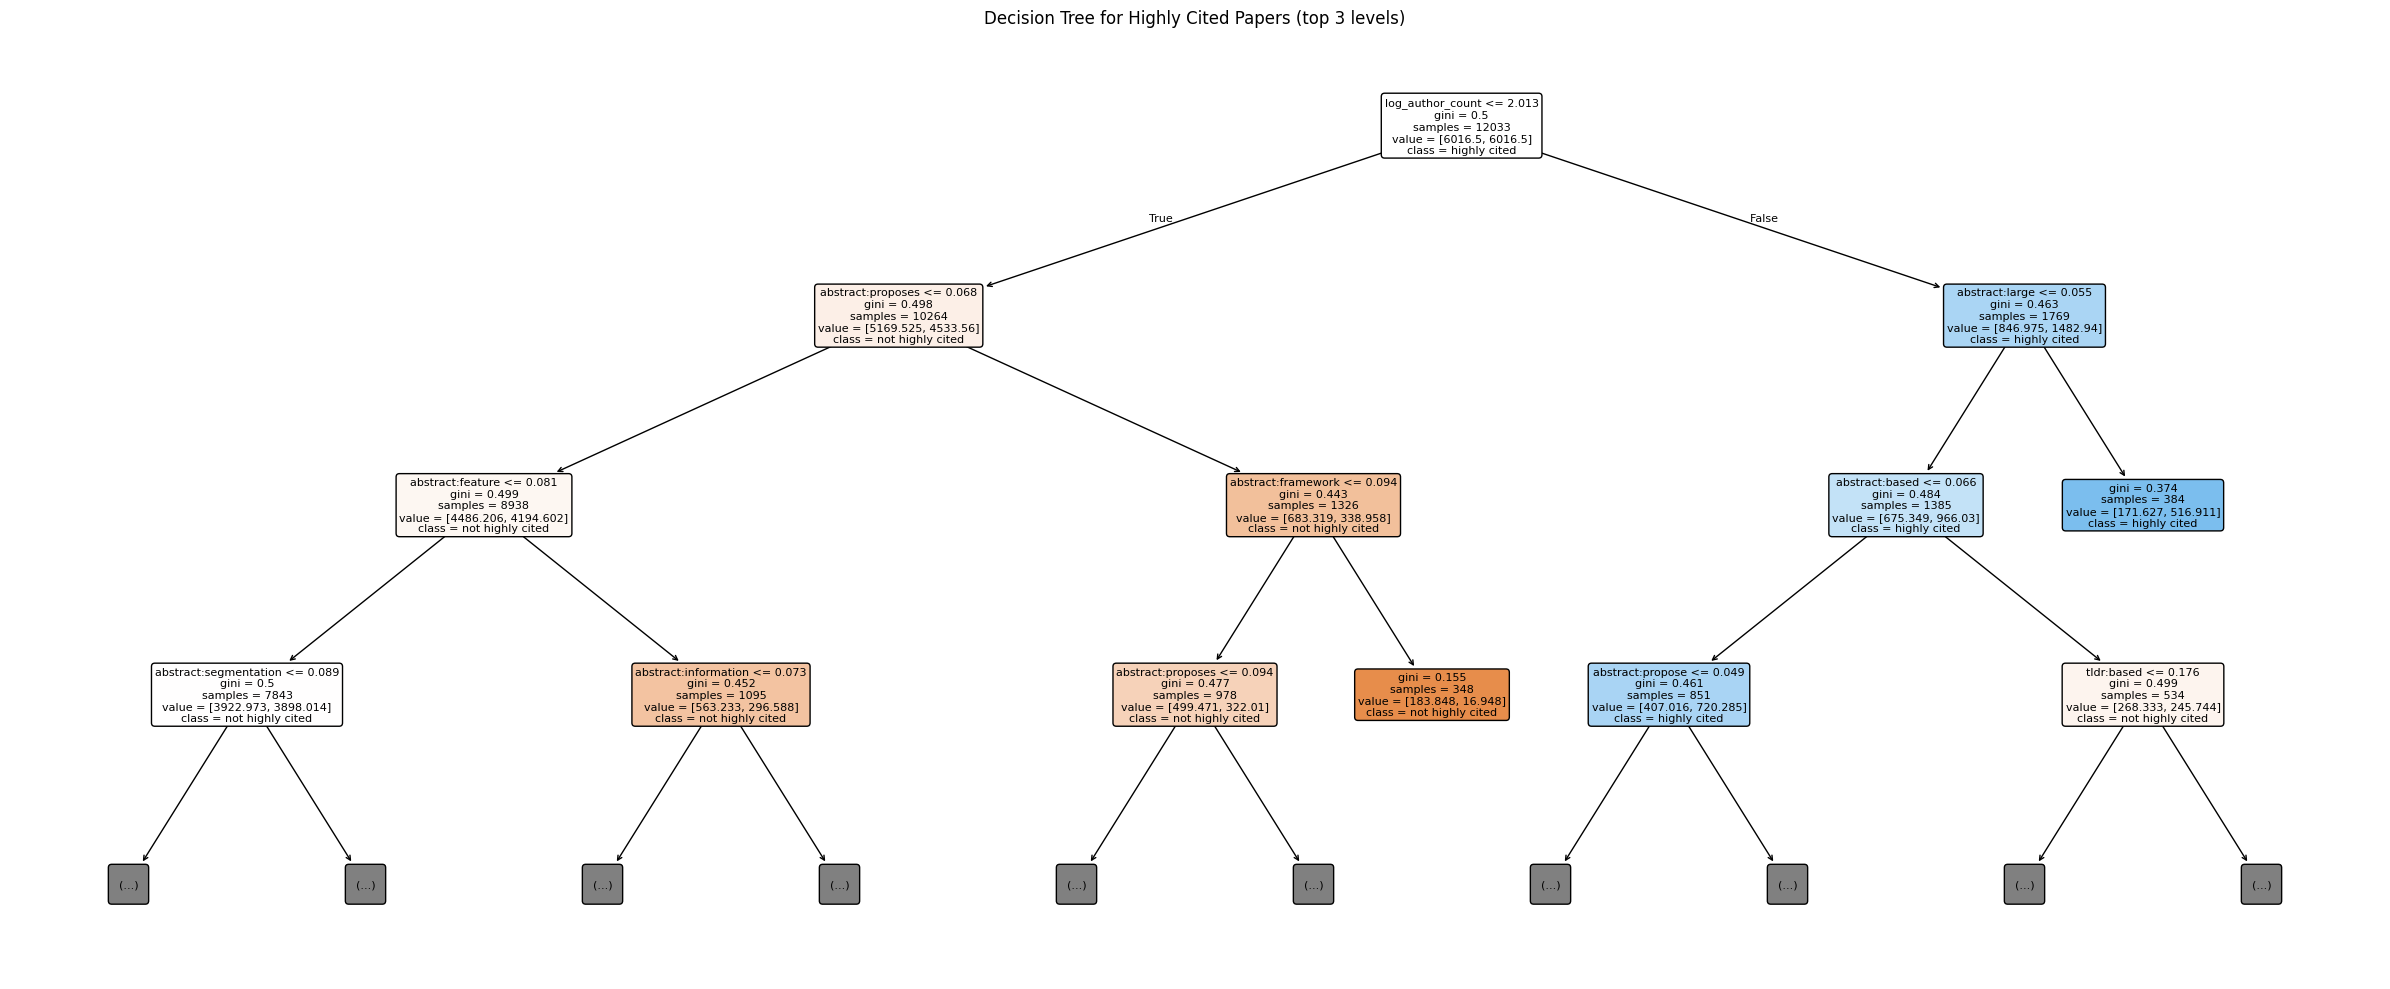

In [12]:
# Visualize the top 3 levels of the decision tree.
plt.figure(figsize=(24, 10))
plot_tree(
    dt_model,
    feature_names=feature_names,
    class_names=["not highly cited", "highly cited"],
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=8,
)
plt.title("Decision Tree for Highly Cited Papers (top 3 levels)")
plt.tight_layout()
plt.show()

### Comments on Performance

- Adding `min_samples_leaf=200` and `min_samples_split=400` regularizes the tree by preventing splits that only explain a tiny handful of papers.
- The target is very imbalanced: in this dataset, only about 5.9% of joined papers have at least one citation, so accuracy is not very informative by itself.
- Compared with the unregularized tree, the regularized tree usually makes fewer false-positive predictions and has fewer leaves, which makes it easier to interpret.
- The improvement is modest: regularization makes the classifier less chaotic, but precision and F1 are still low because citation prediction is noisy and the positive class is rare.
- Shallow trees such as max_depth 2 or 3 stay simple, while medium-depth trees such as max_depth 8 give the model more room to find patterns without fully memorizing the training set.
- For this dataset, the best tree is not necessarily the one with the highest accuracy. F1, precision, and recall are more useful because the positive class is rare.